# Chapter 5: Advanced SQL


## Core Question

How can SQL rank rows without grouping them away, traverse a hierarchy of unknown depth,
and record an automatic audit action when data changes?


## Connection to Chapter 4

Chapter 4 used declarative constraints and transactions. This chapter adds selected
database programming and advanced query features:

- window functions calculate across related rows while retaining detail rows;
- recursive CTEs reuse prior results until no new result is produced;
- triggers respond automatically to a specified data-change event;
- stored routines are introduced only through purpose and interface.

Use a declarative key, foreign key, or `CHECK` when it directly expresses the rule. Do not
replace a visible constraint with a trigger merely because a trigger is automatic.


## Teaching Summary

| Topic | Worked example and practice | Evidence to retain |
|---|---|---|
| Routines and triggers | Routine contract and row-level audit | Contract plus before/after rows |
| Recursive CTEs | Prerequisite graph traversal | Rows produced in each round |
| Ranking functions | Scores with ties | Predicted and observed ranks |
| Window frames | Running values within a partition | Frame definition and checked output |


## Prerequisites and Setup

You should be able to use subqueries, CTEs, aggregates, views, transactions, and
constraints. Run the Chapter 2 setup and then the executable SQL lab cell.

SQLite 3.45.3 supports the supplied triggers, recursive CTEs, and window functions. It
does not install stored functions or procedures through SQL statements. Therefore
the standard-routine reference cell is a source-checked reference, not executed SQLite code.


## Learning Objectives

After completing this chapter, you should be able to:

1. Interpret `RANK`, `DENSE_RANK`, and `ROW_NUMBER` when ties occur.
2. Use `PARTITION BY` and an explicit window frame.
3. Separate a recursive CTE into base and recursive terms and trace new rows by round.
4. Explain how duplicates, cycles, and state columns affect termination.
5. Explain a row-level audit trigger through its event, condition, action, `OLD`, and
   `NEW` values.
6. Distinguish a function, procedure, and trigger by invocation and result.

Complete procedural SQL, external routines, statement-level triggers, product-specific
`PIVOT`, `ROLLUP`, `CUBE`, JDBC, Python database APIs, ODBC, and embedded SQL are
extensions.


## 1. Functions, Procedures, and Triggers

| Mechanism | Invocation | Main result |
|---|---|---|
| Function | Used in an expression or product-specific call | Returns a scalar or table value |
| Procedure | Explicit product-specific call | Performs statements and may expose outputs |
| Trigger | Automatic response to a table event | Performs a predefined action |


### Running the Small Examples

Run this setup cell once. Each small SQL example starts from its displayed input tables in a fresh in-memory SQLite database and closes it afterward. The table definitions and SQL are supplied; Python helper syntax is not an additional learning requirement. Read and predict before running each example. The larger chapter lab remains available later in this notebook. The instructor will select variations for class practice; the additional examples are not separate required assignments.


In [1]:
import sqlite3


def run_small_example(tables, statements):
    """Start with the displayed input again each time; keep no database file."""
    db = sqlite3.connect(":memory:", isolation_level=None)
    db.execute("PRAGMA foreign_keys = ON")
    try:
        for name, definition, rows in tables:
            db.execute(f"CREATE TABLE {name} ({definition})")
            if rows:
                marks = ", ".join("?" for _ in rows[0])
                db.executemany(f"INSERT INTO {name} VALUES ({marks})", rows)
        for label, sql in statements:
            print(label)
            try:
                cursor = db.execute(sql)
                if cursor.description:
                    print(" | ".join(column[0] for column in cursor.description))
                    rows = cursor.fetchall()
                    for row in rows:
                        print(" | ".join("NULL" if value is None else str(value) for value in row))
                    if not rows:
                        print("(no rows)")
                else:
                    print("Statement completed.")
            except sqlite3.IntegrityError:
                print("IntegrityError: the statement was rejected.")
            print()
    finally:
        db.close()


### Small Example: One input value, one calculated result

A routine interface states the input and returned value or effect. The query below checks the body of a department-count function. SQLite does not install a stored SQL function here.

The following data are artificial teaching inputs, not student records.

**Input: course**

| id | dept | credits |
| --- | --- | --- |
| DB | IM | 3 |
| WEB | IM | 2 |
| FIN | FN | 3 |

**Predict before checking.** Predict the function-body count for IM and for a department code that is absent.


In [2]:
tables = [('course',
  'id TEXT NOT NULL PRIMARY KEY, dept TEXT, credits INTEGER',
  [['DB', 'IM', 3], ['WEB', 'IM', 2], ['FIN', 'FN', 3]])]
statements = [
    ('Count for IM', """
SELECT COUNT(*) AS n FROM course WHERE dept='IM'
"""),
    ('Count for ZZ', """
SELECT COUNT(*) AS n FROM course WHERE dept='ZZ'
"""),
]
run_small_example(tables, statements)


Count for IM
n
2

Count for ZZ
n
0



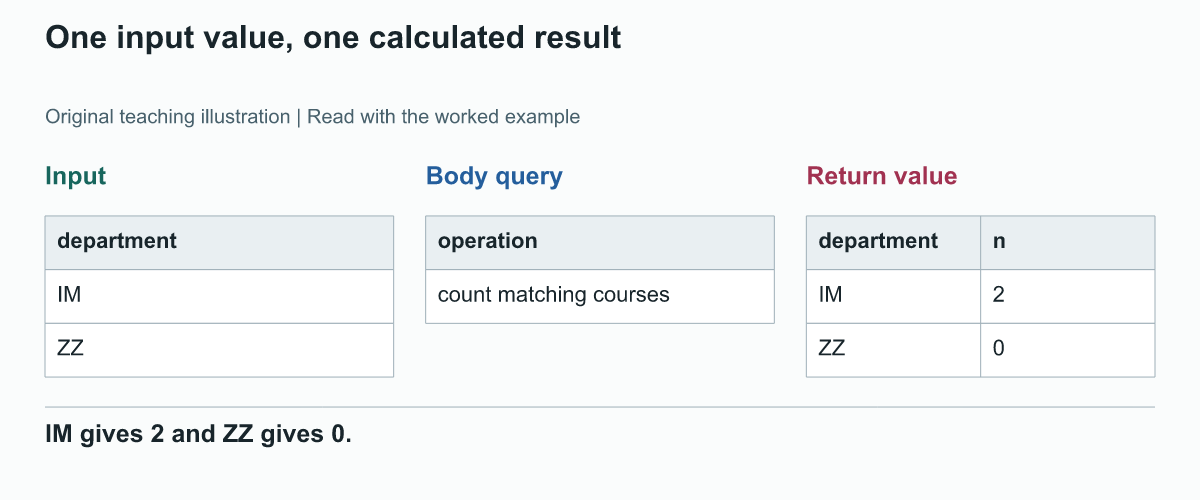


**Read the result.** IM gives 2 and ZZ gives 0. The count has a defined result even when no row matches. This checks the calculation, not stored-routine installation or an application's full error policy.

**Try a change.** Describe a procedure that changes one course's credits. State its two inputs and what an absent course ID should mean; verify the proposed UPDATE target with SELECT.

**Check your reasoning.** Distinguish a returned count from a data modification and from an automatically triggered action. Do not report a procedure as installed in SQLite.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Function Contract Example

A function that receives a course identifier and returns enrollment count has this
logical contract:

```sql
SELECT COUNT(*)
FROM enrollment
WHERE course_id = :p_course_id;
```

DB201 and FT210 return 2; ML230 and WD120 return 1. The lab verifies these data results
with an equivalent query. It does not prove that a stored function was installed.

Practice: define the input, return type, and equivalent query for
`department_course_count`. IM should return 2, FIN and DES 1, and a missing department 0.


### Procedure Contract Example

A procedure may accept a course identifier and new credits, then perform:

```sql
UPDATE course
SET credits = :p_credits
WHERE course_id = :p_course_id;
```

The interface must also define what happens if no course exists: error, returned status,
or allowed no-op. Schema constraints should still reject invalid credits instead of
hiding all validation in the procedure.


## 2. Row-Level Audit Trigger

A trigger design identifies its event, timing, row or statement level, condition, and
action. The supplied SQLite trigger records a grade change:

```sql
CREATE TRIGGER enrollment_grade_audit
AFTER UPDATE OF grade ON enrollment
FOR EACH ROW
WHEN OLD.grade IS NOT NEW.grade
BEGIN
    INSERT INTO enrollment_audit (
        action_name, student_id, course_id, term, old_grade, new_grade
    ) VALUES (
        'GRADE_UPDATE', NEW.student_id, NEW.course_id, NEW.term,
        OLD.grade, NEW.grade
    );
END;
```

Changing S103/DB201 from B to B+ records old value B and new value B+. SQLite `IS NOT`
performs a null-safe difference test. `OLD.grade <> NEW.grade` could become `UNKNOWN`
when one side is `NULL` and miss a real change.

The audit insert is in the same transaction as the original update. Rolling back the
grade change also removes its audit row.


### One grade change and its audit row

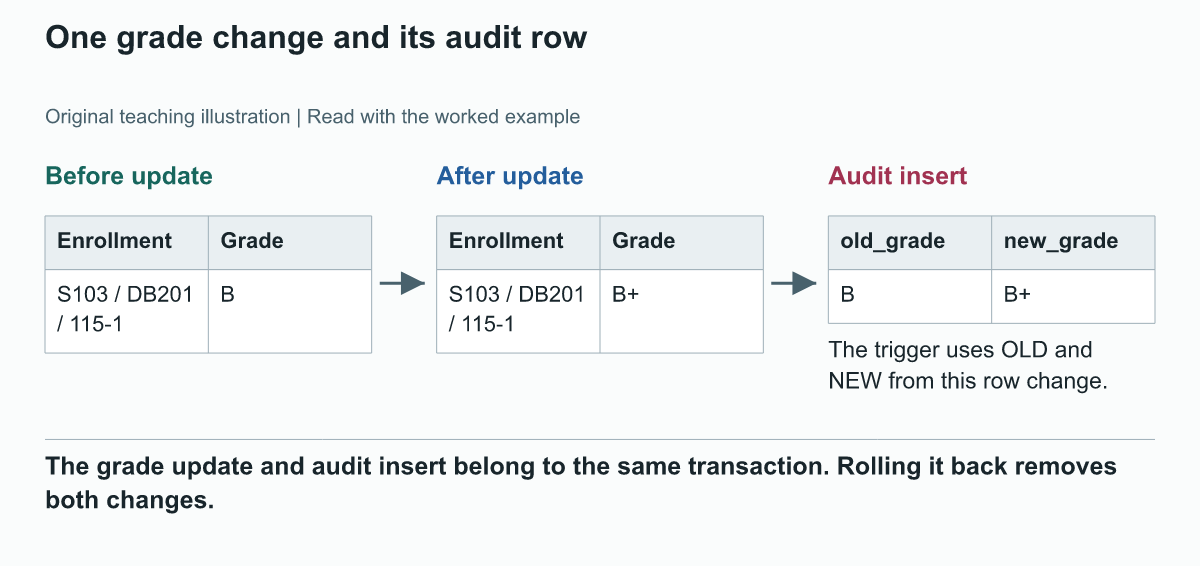

The grade update and audit insert belong to the same transaction. Rolling it back removes both changes.


### Small Example: Record a transition from ungraded to graded

An AFTER UPDATE trigger can inspect OLD and NEW values. SQLite IS NOT detects a changed value even when one side is NULL; an ordinary inequality does not reliably do that.

The following data are artificial teaching inputs, not student records.

**Input: grade**

| sid | value |
| --- | --- |
| S1 | NULL |

**Input: audit**

| old_value | new_value |
| --- | --- |

The input table is empty.

**Predict before checking.** Will changing NULL to B create one audit row? Will assigning B a second time create another?


In [3]:
tables = [('grade', 'sid TEXT NOT NULL PRIMARY KEY, value TEXT', [['S1', None]]),
 ('audit', 'old_value TEXT, new_value TEXT', [])]
statements = [
    ('Define trigger', """
CREATE TRIGGER record_grade AFTER UPDATE OF value ON grade FOR EACH ROW WHEN OLD.value IS NOT NEW.value BEGIN INSERT INTO audit VALUES (OLD.value,NEW.value); END
"""),
    ('First update', """
UPDATE grade SET value='B' WHERE sid='S1'
"""),
    ('Same value again', """
UPDATE grade SET value='B' WHERE sid='S1'
"""),
    ('Audit rows', """
SELECT old_value,new_value FROM audit
"""),
]
run_small_example(tables, statements)


Define trigger
Statement completed.

First update
Statement completed.

Same value again
Statement completed.

Audit rows
old_value | new_value
NULL | B



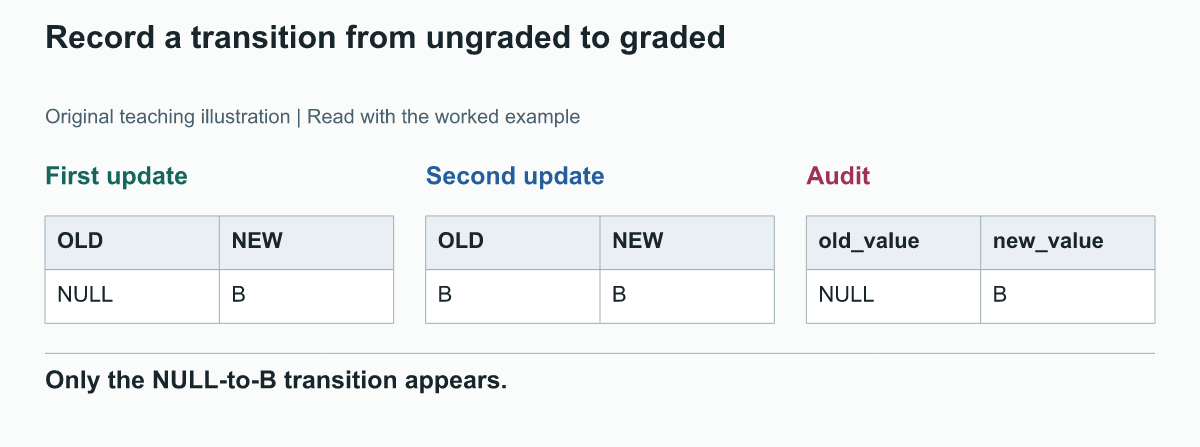


**Read the result.** Only the NULL-to-B transition appears. The second update leaves the value unchanged, so the WHEN condition prevents an extra audit record.

**Try a change.** Change B back to NULL and inspect the second audit row. Explain which value belongs to OLD and which to NEW.

**Check your reasoning.** Count actual changes, not UPDATE statements. Keep the nullable case; it is the reason for the null-safe comparison.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Practice

Design an enrollment-delete audit. A delete has an `OLD` row but no `NEW` row. Inside a
savepoint, delete one enrollment, confirm exactly one correct audit row, and roll back.


### When Not to Use a Trigger

Use a foreign key for an enrollment-to-course reference and a `CHECK` for a priority
range. A trigger is appropriate for audit history because the old and new transition
values must be recorded. Hidden trigger chains and unexpected side effects must be tested.


## 3. Recursive CTEs

The prerequisite data is:

```text
DB201 <- WD120
FT210 <- DB201
ML230 <- DB201
```

The right side is a prerequisite of the left side.

```sql
WITH RECURSIVE all_prereq(course_id, prereq_id) AS (
    SELECT course_id, prereq_id
    FROM course_prerequisite

    UNION

    SELECT ap.course_id, cp.prereq_id
    FROM all_prereq AS ap
    JOIN course_prerequisite AS cp
      ON cp.course_id = ap.prereq_id
)
SELECT course_id, prereq_id
FROM all_prereq;
```

The base term returns direct prerequisite pairs. The recursive term follows one more
edge. The first recursive round adds FT210/WD120 and ML230/WD120. The next round adds no
new pair, so the fixed point contains five pairs.


### Follow prerequisite edges until no new pair appears

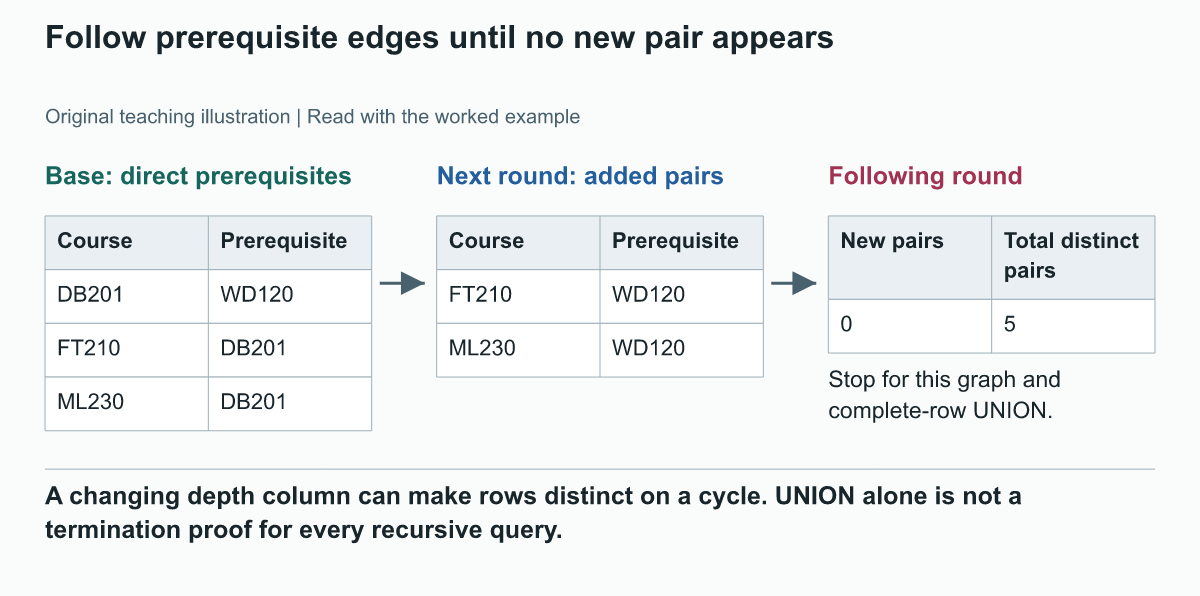

A changing depth column can make rows distinct on a cycle. UNION alone is not a termination proof for every recursive query.


### Small Example: Follow a chain one edge at a time

The base term returns the direct prerequisites of C. The recursive term follows an edge from the current node. UNION removes repeated complete result rows; here each result row contains just node, so a known node is not added again.

The following data are artificial teaching inputs, not student records.

**Input: edge**

| course | prerequisite |
| --- | --- |
| C | B |
| B | A |

**Predict before checking.** Starting at C, which prerequisites appear in the base term and after one recursive step?


In [4]:
tables = [('edge', 'course TEXT, prerequisite TEXT', [['C', 'B'], ['B', 'A']])]
statements = [
    ('Prerequisites of C', """
WITH RECURSIVE reach(node) AS (SELECT prerequisite FROM edge WHERE course='C' UNION SELECT e.prerequisite FROM edge e JOIN reach r ON e.course=r.node) SELECT node FROM reach ORDER BY node
"""),
]
run_small_example(tables, statements)


Prerequisites of C
node
A
B



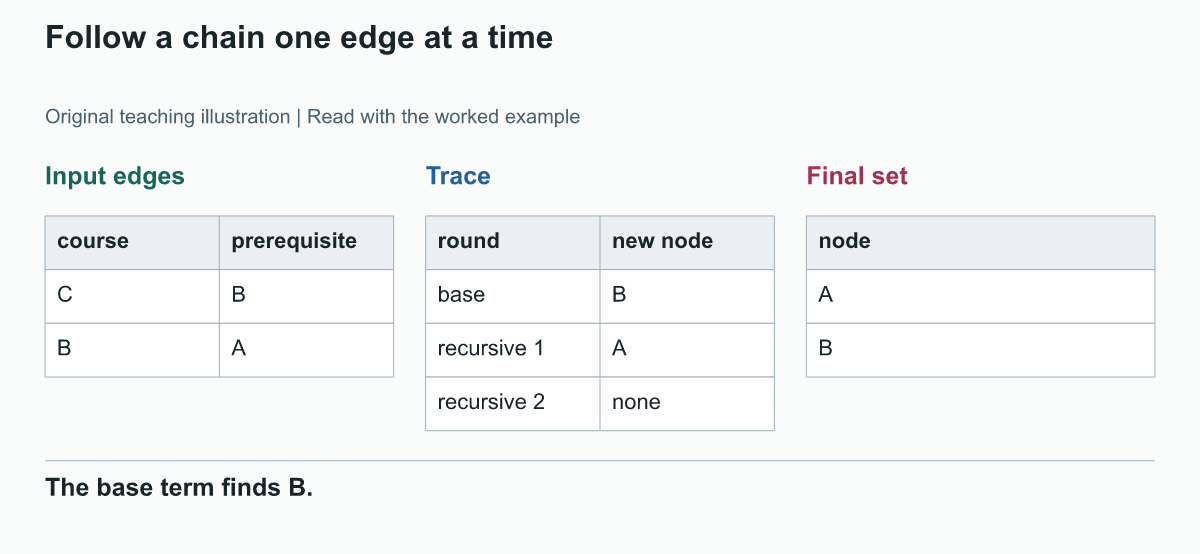


**Read the result.** The base term finds B. Following B's edge adds A. A has no outgoing prerequisite edge, so no further node is added. The final ORDER BY sorts labels; it does not show discovery order.

**Try a change.** Add edge A to Z and predict the additional recursive step. Then explain why adding a changing depth column would require a new termination argument on cyclic data.

**Check your reasoning.** Trace edge direction and complete-row duplicate removal separately. A depth limit alone would not prove the data is acyclic.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Predict and Check

Trace FT210 only. DB201 has depth 1 and WD120 depth 2. Run the base term by itself before
running the full query. If the direction is reversed, the query answers which courses
depend on FT210, which is a different question.


### Cycles and Termination

`UNION` removes duplicate complete rows. `UNION ALL` retains them and may continue
indefinitely on a cycle without a guard. Even `UNION` may not stop a depth query if each
round creates a new depth value, because the complete row is different.

Possible controls include prohibiting cycles, retaining and checking a visited path, or
using a requirement-based maximum depth. A maximum depth limits output but does not prove
that the graph is acyclic.


## 4. Ranking Functions

The best scores are S101=92, S102=92, S103=84, and S104=84.

```sql
WITH best_score AS (
    SELECT student_id, MAX(score) AS best_score
    FROM sql_practice_score
    GROUP BY student_id
)
SELECT student_id,
       best_score,
       RANK() OVER (ORDER BY best_score DESC) AS score_rank,
       DENSE_RANK() OVER (ORDER BY best_score DESC) AS dense_score_rank,
       ROW_NUMBER() OVER (
           ORDER BY best_score DESC, student_id
       ) AS display_row
FROM best_score;
```

| Student | Score | `RANK` | `DENSE_RANK` | `ROW_NUMBER` |
|---|---:|---:|---:|---:|
| S101 | 92 | 1 | 1 | 1 |
| S102 | 92 | 1 | 1 | 2 |
| S103 | 84 | 3 | 2 | 3 |
| S104 | 84 | 3 | 2 | 4 |

`RANK` leaves a gap after a tie. `DENSE_RANK` does not. `ROW_NUMBER` assigns a unique
number to every row; the additional student identifier makes the order deterministic.

Practice: change S103 to 92 and predict all three numberings before executing the query.


### Ties distinguish the three ranking functions

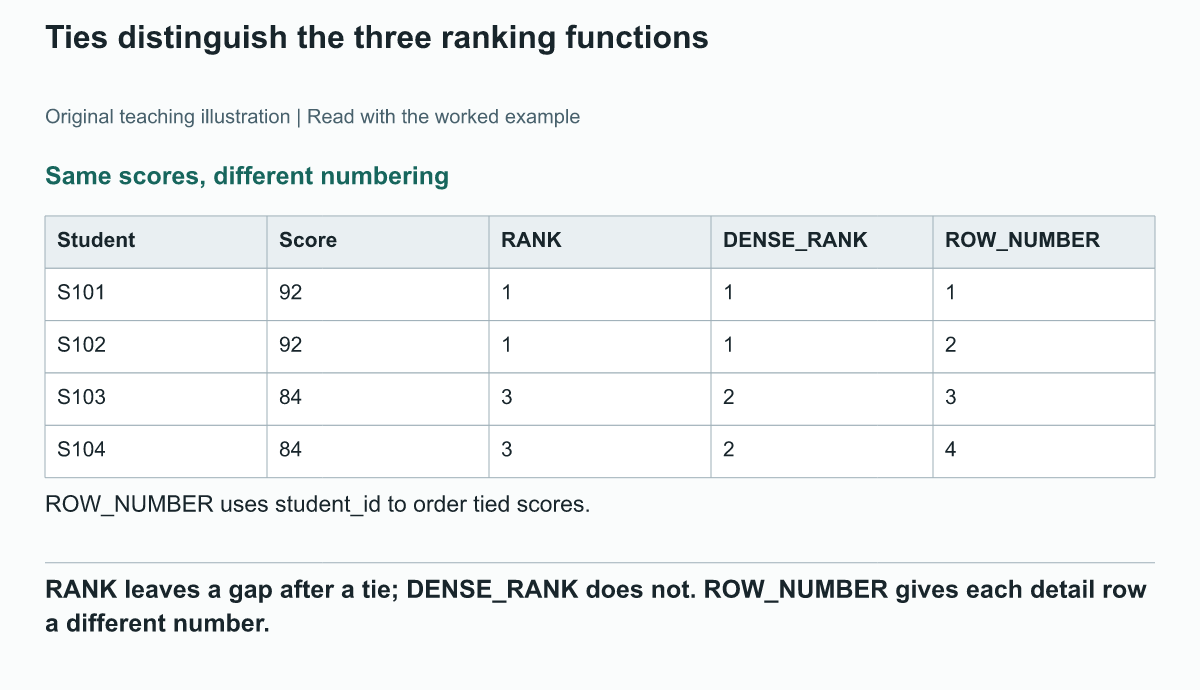

RANK leaves a gap after a tie; DENSE_RANK does not. ROW_NUMBER gives each detail row a different number.


## 5. Partitions and Window Frames

`PARTITION BY` restarts a window calculation for each group without collapsing detail
rows. `ORDER BY` defines sequence inside the partition, and the frame identifies the rows
used for the current calculation.

```sql
SELECT student_id,
       attempt_no,
       score,
       ROUND(
           AVG(score) OVER (
               PARTITION BY student_id
               ORDER BY attempt_no
               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
           ),
           1
       ) AS running_average
FROM sql_practice_score;
```

S101 has running averages 78 and 85. Unlike `GROUP BY`, the result retains each attempt.

Practice: change the frame to
`ROWS BETWEEN 1 PRECEDING AND CURRENT ROW`, add a third attempt, and compare the moving
two-row average with the running average. State the frame explicitly rather than relying
on a DBMS default.


### Small Example: A running total keeps each detail row

GROUP BY combines rows. A window calculation can retain every row and compute a value over related rows. Here PARTITION BY restarts the total for each student, and the explicit ROWS frame includes the current and preceding rows.

The following data are artificial teaching inputs, not student records.

**Input: attempt**

| sid | attempt_no | points |
| --- | --- | --- |
| S1 | 1 | 10 |
| S1 | 2 | 20 |
| S1 | 3 | 30 |
| S2 | 1 | 7 |

**Predict before checking.** Predict S1's three running totals and S2's first total. How many output rows remain?


In [5]:
tables = [('attempt',
  'sid TEXT, attempt_no INTEGER, points INTEGER',
  [['S1', 1, 10], ['S1', 2, 20], ['S1', 3, 30], ['S2', 1, 7]])]
statements = [
    ('Running totals', """
SELECT sid,attempt_no,SUM(points) OVER (PARTITION BY sid ORDER BY attempt_no ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS total FROM attempt ORDER BY sid,attempt_no
"""),
]
run_small_example(tables, statements)


Running totals
sid | attempt_no | total
S1 | 1 | 10
S1 | 2 | 30
S1 | 3 | 60
S2 | 1 | 7



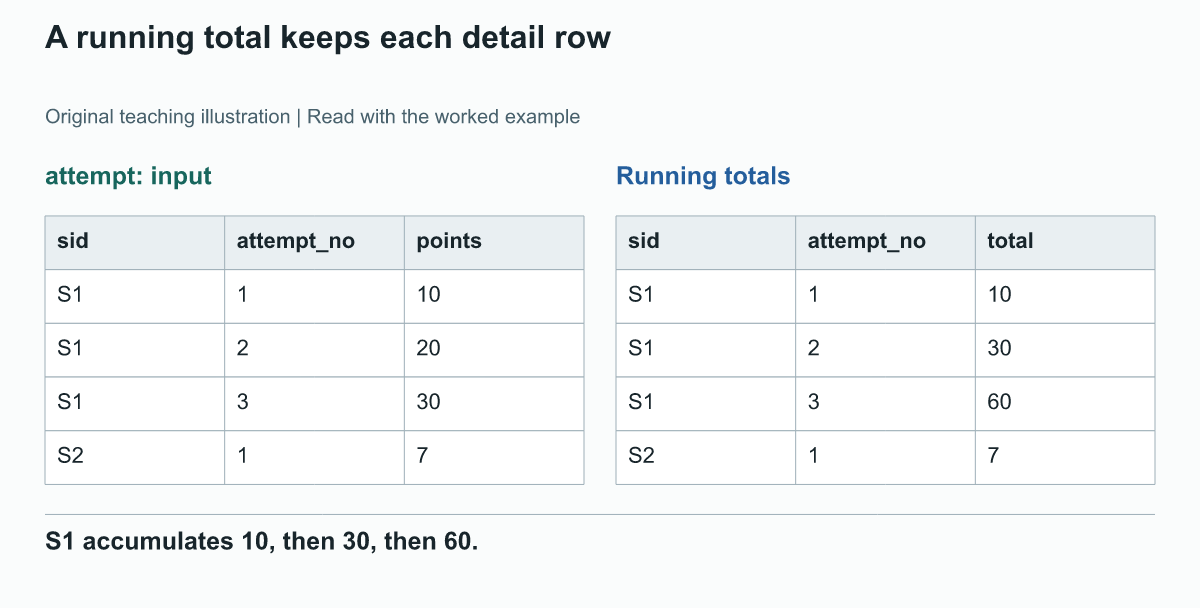


**Read the result.** S1 accumulates 10, then 30, then 60. S2 starts a new partition at 7. All four attempts remain visible; a grouped student total would return only two rows.

**Try a change.** Change the frame to 1 PRECEDING AND CURRENT ROW. Predict the total for S1's third attempt and explain which earlier row is excluded.

**Check your reasoning.** Write the included attempt numbers for each frame before adding the points.

When this variation is assigned, retain your prediction, result, and correction or explanation.


## 6. Short Extension: Conditional Aggregation

```sql
SELECT student_id,
       MAX(CASE WHEN attempt_no = 1 THEN score END) AS attempt_1,
       MAX(CASE WHEN attempt_no = 2 THEN score END) AS attempt_2
FROM sql_practice_score
GROUP BY student_id
ORDER BY student_id;
```

This fixed cross-tab does not add a new result column when attempt 3 appears. Dynamic
categories require application code or product-specific dynamic pivot features.


### Small Example: Turn known attempt numbers into fixed columns

CASE chooses the values for a particular output column. MAX then reduces each student's matching value to one cell. This short illustration is extension reading, not a new required pivot language.

The following data are artificial teaching inputs, not student records.

**Input: score**

| sid | attempt | points |
| --- | --- | --- |
| S1 | 1 | 6 |
| S1 | 2 | 9 |
| S2 | 1 | 8 |

**Predict before checking.** What will the second-attempt column contain for S2?


In [6]:
tables = [('score',
  'sid TEXT, attempt INTEGER, points INTEGER',
  [['S1', 1, 6], ['S1', 2, 9], ['S2', 1, 8]])]
statements = [
    ('Fixed columns', """
SELECT sid,MAX(CASE WHEN attempt=1 THEN points END) AS first,MAX(CASE WHEN attempt=2 THEN points END) AS second FROM score GROUP BY sid ORDER BY sid
"""),
]
run_small_example(tables, statements)


Fixed columns
sid | first | second
S1 | 6 | 9
S2 | 8 | NULL



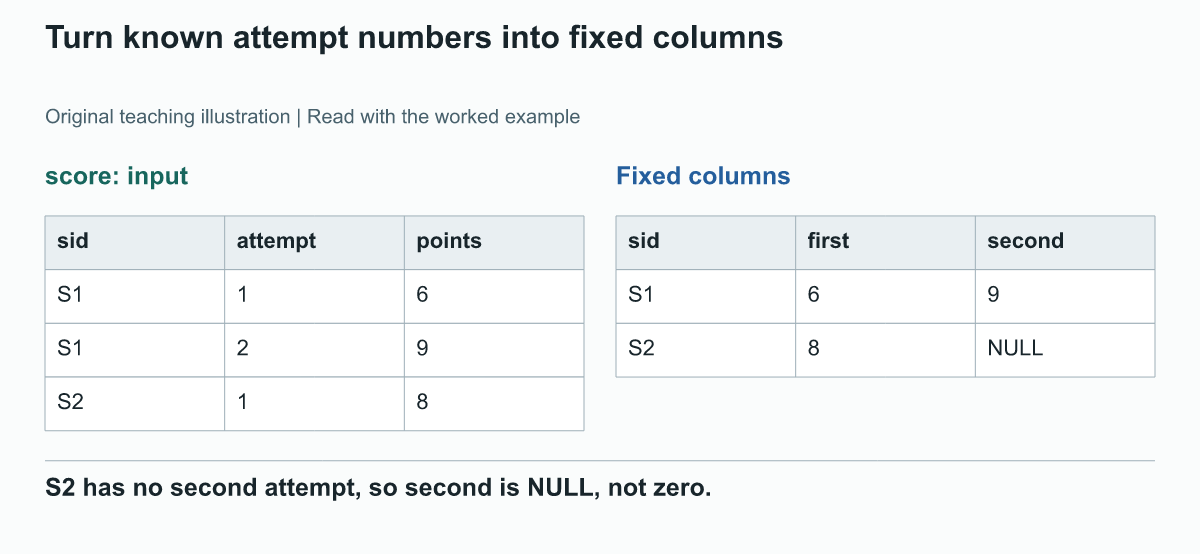


**Read the result.** S2 has no second attempt, so second is NULL, not zero. The CASE expressions define exactly two attempt columns.

**Try a change.** As optional practice, add attempt 3. Explain why the result does not automatically gain a third column.

**Check your reasoning.** Separate missing observations from zero points and fixed output columns from changing categories.

When this variation is assigned, retain your prediction, result, and correction or explanation.


## Common Errors

1. Reporting reference routine code as executed SQLite code.
2. Omitting the input, output, or invocation contract of a routine.
3. Comparing nullable transition values with a non-null-safe operator.
4. Reimplementing a declarative constraint with a trigger.
5. Reversing a recursive edge.
6. Using `UNION ALL` on a cyclic graph without a guard.
7. Treating `ROW_NUMBER` as a tie-aware rank.
8. Assuming a window's internal order is the final display order.
9. Omitting a window frame while assuming running-row behavior.


## Classroom and Individual Evidence

Review three proposed solutions: a trigger that reimplements a foreign key, a recursive
CTE without a termination explanation, and a ranking that treats `ROW_NUMBER` as rank.
Judge mechanism fit, termination, tie handling, deterministic order, and execution claims.

Retain the routine contract, trigger before/after evidence, recursive rounds, ranking
prediction, window-frame result, and individually corrected solution.


## Chapter Summary

Functions return values, procedures perform explicitly requested work, and triggers run
in response to a specified database event. Recursive CTEs require a correct direction and a
termination argument. Ranking functions differ in tie handling, while partitions and
frames define the rows used by a window calculation. Chapter 6 returns to database
design and business rules.


## After-Class Continuation

Choose one recursive CTE or window query and vary one condition, edge, ordering column,
or frame boundary. Predict the effect first, run the revised query, and explain the result
without generalizing beyond the tested data and DBMS.


## Build and Inspect the Chapter Database

The executable cells use SQLite through Python's standard `sqlite3` module. Follow the
cells in order:

1. Open a database connection and enable foreign-key enforcement.
2. Execute the chapter's `CREATE TABLE` statements before inserting rows.
3. Load the synthetic example data.
4. Inspect the resulting tables, columns, primary keys, and foreign keys.
5. Check referential integrity before running the chapter queries.
6. Predict each query result, execute it, and explain any difference.

`DATABASE_NAME` is initially `:memory:`. The database disappears when its connection
closes; closing a browser tab alone may leave the kernel and connection running.
Change it to a filename such as `chapter_database.db` when you want SQLite to create a
persistent database in the notebook's working directory. Do not switch to a persistent
file until the in-memory version runs successfully from top to bottom.


In [7]:
import sqlite3

print(f"Python {__import__('sys').version.split()[0]}; SQLite {sqlite3.sqlite_version}")
DATABASE_NAME = ":memory:"  # Change to "chapter_database.db" to keep a database file.
connection = sqlite3.connect(DATABASE_NAME, isolation_level=None)
connection.execute("PRAGMA foreign_keys = ON")


def run_sql_script(connection, script, max_rows=20):
    """Execute a SQLite script and display result-producing statements."""
    buffer = ""
    for raw_line in script.splitlines():
        stripped = raw_line.strip()
        if stripped.startswith(".print"):
            message = stripped[len(".print"):].strip().strip("\"'")
            print(f"\n{message}")
            continue
        buffer += raw_line + "\n"
        if not sqlite3.complete_statement(buffer):
            continue
        statement = buffer.strip()
        buffer = ""
        if not statement:
            continue
        cursor = connection.execute(statement)
        if cursor.description:
            columns = [column[0] for column in cursor.description]
            rows = cursor.fetchmany(max_rows + 1)
            print(" | ".join(columns))
            for row in rows[:max_rows]:
                print(" | ".join("NULL" if value is None else str(value) for value in row))
            if len(rows) > max_rows:
                print(f"... additional rows omitted after {max_rows}")
    remaining = "\n".join(
        line for line in buffer.splitlines() if not line.strip().startswith("--")
    ).strip()
    if remaining:
        raise ValueError("The embedded SQL ends with an incomplete statement.")


def inspect_database(connection):
    """Display tables, columns, primary keys, foreign keys, and integrity status."""
    tables = [
        row[0]
        for row in connection.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name"
        )
    ]
    print("Tables:", ", ".join(tables) if tables else "none")
    for table in tables:
        columns = connection.execute(f'PRAGMA table_info("{table}")').fetchall()
        primary_key = [row[1] for row in sorted(columns, key=lambda row: row[5]) if row[5]]
        print(f"\n{table}")
        print("  columns:", ", ".join(f"{row[1]} {row[2]}" for row in columns))
        print("  primary key:", ", ".join(primary_key) if primary_key else "none")
        for index_row in connection.execute(f'PRAGMA index_list("{table}")').fetchall():
            if index_row[2] and index_row[3] == "u":
                unique_columns = [
                    row[2]
                    for row in connection.execute(
                        f'PRAGMA index_info("{index_row[1]}")'
                    ).fetchall()
                ]
                print("  unique constraint:", ", ".join(unique_columns))
        foreign_keys = connection.execute(f'PRAGMA foreign_key_list("{table}")').fetchall()
        for foreign_key in foreign_keys:
            print(f"  foreign key: {foreign_key[3]} -> {foreign_key[2]}.{foreign_key[4]}")
    violations = connection.execute("PRAGMA foreign_key_check").fetchall()
    print("\nForeign-key check:", "PASS" if not violations else violations)


Python 3.12.9; SQLite 3.45.3


### Course-registration setup


In [8]:
SQL_1 = """PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS enrollment;
DROP TABLE IF EXISTS course;
DROP TABLE IF EXISTS student;
DROP TABLE IF EXISTS department;

CREATE TABLE department (
    dept_code TEXT NOT NULL PRIMARY KEY,
    dept_name TEXT NOT NULL UNIQUE,
    building TEXT NOT NULL
);

CREATE TABLE student (
    student_id TEXT NOT NULL PRIMARY KEY,
    email TEXT NOT NULL UNIQUE,
    student_name TEXT NOT NULL,
    dept_code TEXT NOT NULL,
    FOREIGN KEY (dept_code) REFERENCES department (dept_code)
);

CREATE TABLE course (
    course_id TEXT NOT NULL PRIMARY KEY,
    title TEXT NOT NULL,
    dept_code TEXT NOT NULL,
    credits INTEGER NOT NULL CHECK (credits BETWEEN 1 AND 6),
    FOREIGN KEY (dept_code) REFERENCES department (dept_code)
);

CREATE TABLE enrollment (
    student_id TEXT NOT NULL,
    course_id TEXT NOT NULL,
    term TEXT NOT NULL,
    grade TEXT,
    PRIMARY KEY (student_id, course_id, term),
    FOREIGN KEY (student_id) REFERENCES student (student_id),
    FOREIGN KEY (course_id) REFERENCES course (course_id)
);

INSERT INTO department (dept_code, dept_name, building) VALUES
    ('DES', 'Digital Design', 'Hong Hall'),
    ('FIN', 'Finance', 'Cheng Hall'),
    ('IM', 'Information Management', 'Hong Hall');

INSERT INTO student (student_id, email, student_name, dept_code) VALUES
    ('S101', 'an.chen@example.edu', 'An Chen', 'IM'),
    ('S102', 'bea.lin@example.edu', 'Bea Lin', 'FIN'),
    ('S103', 'kai.wu@example.edu', 'Kai Wu', 'IM'),
    ('S104', 'mira.ho@example.edu', 'Mira Ho', 'DES');

INSERT INTO course (course_id, title, dept_code, credits) VALUES
    ('DB201', 'Database Management', 'IM', 3),
    ('FT210', 'Financial Technology', 'FIN', 3),
    ('ML230', 'Machine Learning', 'IM', 3),
    ('WD120', 'Web Design', 'DES', 2);

INSERT INTO enrollment (student_id, course_id, term, grade) VALUES
    ('S101', 'DB201', '115-1', 'A'),
    ('S101', 'FT210', '115-1', 'B+'),
    ('S102', 'FT210', '115-1', 'A-'),
    ('S103', 'DB201', '115-1', 'B'),
    ('S103', 'ML230', '115-1', 'A'),
    ('S104', 'WD120', '115-1', 'A-');
"""


In [9]:
run_sql_script(connection, SQL_1)


### Inspect the Database You Created

Read the output as a schema check: confirm the table names, column types, primary-key order, foreign-key direction, and integrity result.


In [10]:
inspect_database(connection)


Tables: course, department, enrollment, student

course
  columns: course_id TEXT, title TEXT, dept_code TEXT, credits INTEGER
  primary key: course_id
  foreign key: dept_code -> department.dept_code

department
  columns: dept_code TEXT, dept_name TEXT, building TEXT
  primary key: dept_code
  unique constraint: dept_name

enrollment
  columns: student_id TEXT, course_id TEXT, term TEXT, grade TEXT
  primary key: student_id, course_id, term
  foreign key: course_id -> course.course_id
  foreign key: student_id -> student.student_id

student
  columns: student_id TEXT, email TEXT, student_name TEXT, dept_code TEXT
  primary key: student_id
  unique constraint: email
  foreign key: dept_code -> department.dept_code

Foreign-key check: PASS


### Advanced SQL lab


In [11]:
SQL_2 = """-- Chapter 5: selected Advanced SQL topics
-- Verified with SQLite 3.45.3. Run Chapter 2 course_registration_setup.sql first.
-- Predict rows, ties, NULLs, and side effects before each block.

PRAGMA foreign_keys = ON;

-- Example 1: executable baseline for the unexecuted stored-function example.
-- SQLite cannot install CREATE FUNCTION through SQL, so this query verifies the
-- expected body result for each course.
SELECT c.course_id,
       (
           SELECT COUNT(*)
           FROM enrollment AS e
           WHERE e.course_id = c.course_id
       ) AS enrollment_count
FROM course AS c
ORDER BY c.course_id;

-- Example 2: execute and roll back the body action of the procedure reference.
-- This does not create or call a stored procedure in SQLite.
SAVEPOINT procedure_body_demo;
UPDATE course
SET credits = 4
WHERE course_id = 'DB201';
SELECT course_id, credits FROM course WHERE course_id = 'DB201';
ROLLBACK TO procedure_body_demo;
RELEASE procedure_body_demo;
SELECT course_id, credits FROM course WHERE course_id = 'DB201';

-- Example 3: row-level audit trigger using SQLite OLD and NEW transition rows.
DROP TRIGGER IF EXISTS enrollment_grade_audit;
DROP TABLE IF EXISTS enrollment_audit;

CREATE TABLE enrollment_audit (
    audit_id INTEGER PRIMARY KEY,
    action_name TEXT NOT NULL,
    student_id TEXT NOT NULL,
    course_id TEXT NOT NULL,
    term TEXT NOT NULL,
    old_grade TEXT,
    new_grade TEXT
);

CREATE TRIGGER enrollment_grade_audit
AFTER UPDATE OF grade ON enrollment
FOR EACH ROW
WHEN OLD.grade IS NOT NEW.grade
BEGIN
    INSERT INTO enrollment_audit (
        action_name, student_id, course_id, term, old_grade, new_grade
    ) VALUES (
        'GRADE_UPDATE', NEW.student_id, NEW.course_id, NEW.term,
        OLD.grade, NEW.grade
    );
END;

SAVEPOINT trigger_demo;

UPDATE enrollment
SET grade = 'B+'
WHERE student_id = 'S103'
  AND course_id = 'DB201'
  AND term = '115-1';

SELECT action_name, student_id, course_id, term, old_grade, new_grade
FROM enrollment_audit
ORDER BY audit_id;

ROLLBACK TO trigger_demo;
RELEASE trigger_demo;

SELECT COUNT(*) AS audit_rows_after_rollback
FROM enrollment_audit;

-- Example 4: prerequisite relation for recursive queries.
DROP TABLE IF EXISTS course_prerequisite;

CREATE TABLE course_prerequisite (
    course_id TEXT NOT NULL,
    prereq_id TEXT NOT NULL,
    PRIMARY KEY (course_id, prereq_id),
    FOREIGN KEY (course_id) REFERENCES course (course_id),
    FOREIGN KEY (prereq_id) REFERENCES course (course_id),
    CHECK (course_id <> prereq_id)
);

INSERT INTO course_prerequisite (course_id, prereq_id) VALUES
    ('DB201', 'WD120'),
    ('FT210', 'DB201'),
    ('ML230', 'DB201');

-- Example 5: base term finds direct prerequisites. The recursive term adds one
-- level at a time. UNION removes duplicates so the fixed point can be reached.
WITH RECURSIVE all_prereq(course_id, prereq_id) AS (
    SELECT course_id, prereq_id
    FROM course_prerequisite

    UNION

    SELECT ap.course_id, cp.prereq_id
    FROM all_prereq AS ap
    JOIN course_prerequisite AS cp
      ON cp.course_id = ap.prereq_id
)
SELECT course_id, prereq_id
FROM all_prereq
ORDER BY course_id, prereq_id;

-- Example 6: recursive query for one target, with depth on the acyclic sample.
WITH RECURSIVE prereq_path(prereq_id, depth) AS (
    SELECT prereq_id, 1
    FROM course_prerequisite
    WHERE course_id = 'ML230'

    UNION ALL

    SELECT cp.prereq_id, pp.depth + 1
    FROM prereq_path AS pp
    JOIN course_prerequisite AS cp
      ON cp.course_id = pp.prereq_id
)
SELECT prereq_id, depth
FROM prereq_path
ORDER BY depth, prereq_id;

-- Example 7: practice-score data for ranking and window functions.
DROP TABLE IF EXISTS sql_practice_score;

CREATE TABLE sql_practice_score (
    student_id TEXT NOT NULL,
    attempt_no INTEGER NOT NULL CHECK (attempt_no > 0),
    score INTEGER NOT NULL CHECK (score BETWEEN 0 AND 100),
    PRIMARY KEY (student_id, attempt_no),
    FOREIGN KEY (student_id) REFERENCES student (student_id)
);

INSERT INTO sql_practice_score (student_id, attempt_no, score) VALUES
    ('S101', 1, 78),
    ('S101', 2, 92),
    ('S102', 1, 92),
    ('S103', 1, 84),
    ('S104', 1, 70),
    ('S104', 2, 84);

-- Example 8: RANK leaves gaps after ties; DENSE_RANK does not. ROW_NUMBER
-- always differs and therefore includes student_id as a deterministic tie-breaker.
WITH best_score AS (
    SELECT student_id, MAX(score) AS best_score
    FROM sql_practice_score
    GROUP BY student_id
)
SELECT student_id,
       best_score,
       RANK() OVER (ORDER BY best_score DESC) AS score_rank,
       DENSE_RANK() OVER (ORDER BY best_score DESC) AS dense_score_rank,
       ROW_NUMBER() OVER (
           ORDER BY best_score DESC, student_id
       ) AS display_row
FROM best_score
ORDER BY display_row;

-- Example 9: PARTITION BY restarts the calculation for each student. The frame
-- includes all attempts from the first through the current attempt.
SELECT student_id,
       attempt_no,
       score,
       ROUND(
           AVG(score) OVER (
               PARTITION BY student_id
               ORDER BY attempt_no
               ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
           ),
           1
       ) AS running_average
FROM sql_practice_score
ORDER BY student_id, attempt_no;

-- Example 10: conditional aggregation creates a portable two-attempt cross-tab.
SELECT student_id,
       MAX(CASE WHEN attempt_no = 1 THEN score END) AS attempt_1,
       MAX(CASE WHEN attempt_no = 2 THEN score END) AS attempt_2
FROM sql_practice_score
GROUP BY student_id
ORDER BY student_id;

-- Student practice. Save predictions and actual results.
-- P1. Define the input, returned value, and equivalent SELECT for a function named
--     department_course_count. Do not claim it was installed in SQLite.
-- P2. Explain how the change_course_credits procedure should respond if no course
--     matches. State whether the contract should report an error or affected-row count.
-- P3. Add a DELETE audit trigger for enrollment. Verify OLD values and rollback.
-- P4. Explain why a foreign key or CHECK should be used instead of a trigger when it
--     can directly express the same rule.
-- P5. Query all direct and indirect prerequisites of FT210, including depth.
-- P6. Add a cycle inside a savepoint and explain why UNION reaches a fixed point but
--     the UNION ALL depth query needs explicit cycle protection. Roll back the cycle.
-- P7. Predict RANK, DENSE_RANK, and ROW_NUMBER if S103 improves to 92.
-- P8. Compute a two-attempt moving average with ROWS BETWEEN 1 PRECEDING AND
--     CURRENT ROW, partitioned by student_id.
-- P9. Extend the conditional-aggregation cross-tab with each student's best score.
"""


In [12]:
run_sql_script(connection, SQL_2)


course_id | enrollment_count
DB201 | 2
FT210 | 2
ML230 | 1
WD120 | 1
course_id | credits
DB201 | 4
course_id | credits
DB201 | 3
action_name | student_id | course_id | term | old_grade | new_grade
GRADE_UPDATE | S103 | DB201 | 115-1 | B | B+
audit_rows_after_rollback
0
course_id | prereq_id
DB201 | WD120
FT210 | DB201
FT210 | WD120
ML230 | DB201
ML230 | WD120
prereq_id | depth
DB201 | 1
WD120 | 2
student_id | best_score | score_rank | dense_score_rank | display_row
S101 | 92 | 1 | 1 | 1
S102 | 92 | 1 | 1 | 2
S103 | 84 | 3 | 2 | 3
S104 | 84 | 3 | 2 | 4
student_id | attempt_no | score | running_average
S101 | 1 | 78 | 78.0
S101 | 2 | 92 | 85.0
S102 | 1 | 92 | 92.0
S103 | 1 | 84 | 84.0
S104 | 1 | 70 | 70.0
S104 | 2 | 84 | 77.0
student_id | attempt_1 | attempt_2
S101 | 78 | 92
S102 | 92 | NULL
S103 | 84 | NULL
S104 | 70 | 84


### Standard routine reference

This reference uses standard SQL/PSM syntax and is not executed by SQLite.

```sql
-- Chapter 5 reference: illustrative SQL/PSM-style routines
-- NOT EXECUTABLE IN SQLITE. Stored-routine syntax differs across DBMS products.
-- These examples show the interface and logic taught in the student guide.

-- Function: one input value and one returned scalar value.
CREATE FUNCTION course_enrollment_count(p_course_id VARCHAR(10))
RETURNS INTEGER
BEGIN
    DECLARE result_count INTEGER;
    SELECT COUNT(*) INTO result_count
    FROM enrollment
    WHERE course_id = p_course_id;
    RETURN result_count;
END;

-- Intended use after installation in a DBMS with adapted syntax:
-- SELECT course_id,
--        course_enrollment_count(course_id) AS enrollment_count
-- FROM course;

-- Procedure: performs a database action when invoked explicitly.
CREATE PROCEDURE change_course_credits(
    IN p_course_id VARCHAR(10),
    IN p_credits INTEGER
)
BEGIN ATOMIC
    UPDATE course
    SET credits = p_credits
    WHERE course_id = p_course_id;
END;

-- Intended call after installation in a DBMS with adapted syntax:
-- CALL change_course_credits('DB201', 4);
```


### Reproducibility Check


In [13]:
assert connection.execute("SELECT COUNT(*) FROM department").fetchone()[0] == 3
assert connection.execute("SELECT COUNT(*) FROM student").fetchone()[0] == 4
assert connection.execute("SELECT COUNT(*) FROM course").fetchone()[0] == 4
assert connection.execute("SELECT COUNT(*) FROM enrollment").fetchone()[0] == 6
assert connection.execute("PRAGMA foreign_key_check").fetchall() == []
print("Notebook checks passed.")


Notebook checks passed.


In [14]:
connection.close()
print("Database connection closed.")


Database connection closed.
